# SDSC 3004 Final Project
### Author: Yue ZHU

In [1]:
import numpy as np
# Directly import the specific 2017 benchmark classes
from opfunu.cec_based.cec2017 import F22017, F102017, F172017, F272017

# Define the problem dimension (e.g., D=10, 30, 50)
D = 30 

search_bounds = (-100, 100)

lower_bound, upper_bound = search_bounds

# 1. Unimodal NO.2
prob1 = F22017(ndim=D)

# 2. Simple Multimodal NO.10
prob2 = F102017(ndim=D)

# 3. Hybrid NO.17
prob3 = F172017(ndim=D)

# 4. Composition NO.27
prob4 = F272017(ndim=D)

# Put them in a dictionary for easy iteration
benchmarks = {
    "Unimodal_NO2": prob1,
    "Multimodal_NO10": prob2,
    "Hybrid_NO17": prob3,
    "Composition_NO27": prob4
}

# --- Test the evaluation ---
# Create a random candidate solution 'x' within the [-100, 100] bounds
x_candidate = np.random.uniform(low=-100, high=100, size=D)

# Evaluate the candidate solution on NO.2
fitness_score = benchmarks["Unimodal_NO2"].evaluate(x_candidate)

print(f"Evaluated x on Unimodal NO.2. Fitness score: {fitness_score}")

Evaluated x on Unimodal NO.2. Fitness score: 9392187.635572286


d:\Anaconda\envs\opt\Lib\site-packages\opfunu\cec_based\cec.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Differenti Evolution

In [2]:
import numpy as np
from Differential_Evolution import run_differential_evolution

# Initialize the dictionaries 
de_histories = {}
de_final_scores = {}

search_bounds = (-100, 100)
num_runs = 10  # Number of independent runs for statistical robustness
max_fe_budget = 300000 # Strict CEC 2017 Budget
pop_size = 100

# Calculate exact iterations allowed to hit 300k FEs
allowed_iters = max_fe_budget // pop_size 

# Run the DE algorithm on all 4 problems
for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running DE on {name} ({num_runs} runs) ---")
    print(f"Budget: {max_fe_budget} FEs | Pop: {pop_size} | Iters: {allowed_iters}")
    print(f"==================================================")
    
    # Temporary lists to hold the results of all runs for this specific problem
    current_problem_curves = []
    current_problem_scores = []
    
    # Execute the 10 independent runs
    for run in range(num_runs):
        best_x, best_f, curve = run_differential_evolution(
            objective_func=func, 
            dim=30, # explicitly using 30 as defined in your setup
            bounds=search_bounds,
            pop_size=pop_size,     
            F=0.5,           # Mutation scaling factor
            CR=0.9,          # Crossover rate
            # max_iters=allowed_iters # <--- FORCING THE ITERATION LIMIT
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Ensures this curve is exactly 3000 data points long,
        # perfectly matching Dual Annealing and SASS for a fair plot.
        standard_x = np.linspace(0, max_fe_budget, 3000)
        actual_x = np.linspace(0, max_fe_budget, len(curve))
        standardized_curve = np.interp(standard_x, actual_x, curve)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(best_f)
        
        # Print a status update so you can track progress
        print(f"  Run {run + 1}/{num_runs} completed | Score: {best_f:.4f}")
        
    # --- DATA STORAGE ---
    # By converting to np.array, de_histories[name] safely becomes a 2D matrix of shape (10, 3000)
    de_histories[name] = np.array(current_problem_curves)
    de_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    best_overall = np.min(de_final_scores[name])
    worst_overall = np.max(de_final_scores[name])
    mean_score = np.mean(de_final_scores[name])
    std_score = np.std(de_final_scores[name])
    
    # Calculate the gap between the absolute best result and the theoretical minimum
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running DE on Unimodal_NO2 (10 runs) ---
Budget: 300000 FEs | Pop: 100 | Iters: 3000
  Run 1/10 completed | Score: 664.8665
  Run 2/10 completed | Score: 1776.0663
  Run 3/10 completed | Score: 1585.2208
  Run 4/10 completed | Score: 2219.3195
  Run 5/10 completed | Score: 1625.9715
  Run 6/10 completed | Score: 2680.9749
  Run 7/10 completed | Score: 2244.8827
  Run 8/10 completed | Score: 1233.4797
  Run 9/10 completed | Score: 6650.0691
  Run 10/10 completed | Score: 2683.2664

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          664.8665 (Error Gap: 464.8665)
Mean Score:          2336.4117
Worst Score:         6650.0691
Std Deviation:       1557.6355

--- Running DE on Multimodal_NO10 (10 runs) ---
Budget: 300000 FEs | Pop: 100 | Iters: 3000
  Run 1/10 completed | Score: 66603.6091
  Run 2/10 completed | Score: 17910.5867
  Run 3/10 completed | Score: 28075.6058
  Run 4/10 completed | Score: 65520.4646
  Run 5/10 completed | Score: 94812.6584
  Run 6

In [3]:
import numpy as np
from jde import run_jde

# Initialize the dictionaries
jde_histories = {}
jde_final_scores = {}

search_bounds = (-100, 100)
num_runs = 10  # Number of independent runs for statistical robustness
max_fe_budget = 300000 # Strict CEC 2017 Budget
pop_size = 100

# Run the JDE algorithm on all 4 problems
for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running jDE on {name} ({num_runs} runs) ---")
    print(f"Budget: {max_fe_budget} FEs | Pop: {pop_size}")
    print(f"==================================================")
    
    # Temporary lists to hold the results of all runs for this specific problem
    current_problem_curves = []
    current_problem_scores = []
    
    # Execute the 10 independent runs
    for run in range(num_runs):
        best_x, best_f, curve = run_jde(
            objective_func=func, 
            dim=30, # Explicitly 30D for CEC 2017
            bounds=search_bounds,
            pop_size=pop_size,     # Standard population size
            # max_fes=max_fe_budget  # Pass the 300,000 budget
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Ensures this curve is exactly 3000 data points long,
        # perfectly matching your other algorithms for a fair and clean plot.
        standard_x = np.linspace(0, max_fe_budget, 3000)
        actual_x = np.linspace(0, max_fe_budget, len(curve))
        standardized_curve = np.interp(standard_x, actual_x, curve)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(best_f)
        
        # Print a status update so you can track progress
        print(f"  Run {run + 1}/{num_runs} completed | Score: {best_f:.4f}")
        
    # --- DATA STORAGE ---
    # By converting to np.array, jde_histories[name] safely becomes a 2D matrix of shape (10, 3000)
    jde_histories[name] = np.array(current_problem_curves)
    jde_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    # Calculate summary statistics for your final report tables
    best_overall = np.min(jde_final_scores[name])
    worst_overall = np.max(jde_final_scores[name])
    mean_score = np.mean(jde_final_scores[name])
    std_score = np.std(jde_final_scores[name])
    
    # Calculate the gap between the absolute best result and the theoretical minimum
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running jDE on Unimodal_NO2 (10 runs) ---
Budget: 300000 FEs | Pop: 100
  Run 1/10 completed | Score: 200.0000
  Run 2/10 completed | Score: 200.0000
  Run 3/10 completed | Score: 200.0000
  Run 4/10 completed | Score: 200.0000
  Run 5/10 completed | Score: 200.0000
  Run 6/10 completed | Score: 200.0000
  Run 7/10 completed | Score: 200.0000
  Run 8/10 completed | Score: 200.0000
  Run 9/10 completed | Score: 200.0000
  Run 10/10 completed | Score: 200.0000

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          200.0000 (Error Gap: 0.0000)
Mean Score:          200.0000
Worst Score:         200.0000
Std Deviation:       0.0000

--- Running jDE on Multimodal_NO10 (10 runs) ---
Budget: 300000 FEs | Pop: 100
  Run 1/10 completed | Score: 1539.9257
  Run 2/10 completed | Score: 1164.2271
  Run 3/10 completed | Score: 1028.4394
  Run 4/10 completed | Score: 1128.3550
  Run 5/10 completed | Score: 1266.2717
  Run 6/10 completed | Score: 1025.8889
  Run 7/10 com

In [4]:
import numpy as np
from SASS_algo import sass

# Initialize the dictionaries
SASS_histories = {}
SASS_final_scores = {}

# Make sure you set your number of runs!
num_runs = 10  

# Execute the SASS algorithm on all benchmark problems
for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running Custom SASS on {name} ({num_runs} runs) ---")
    print(f"==================================================")
    
    # Temporary lists to hold the 10 runs
    current_problem_curves = []
    current_problem_scores = []
    
    for run in range(num_runs):
        final_score, best_vector, history = sass(
            objective_func=func,
            dim=30,           # Dimensions 
            pop_size=150,     # Population size
            max_iters=2000    # Number of iterations
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Standardize the curve to exactly 1000 points so it perfectly matches DE/jDE
        standard_x = np.linspace(0, 300000, 3000)
        actual_x = np.linspace(0, 300000, len(history))
        standardized_curve = np.interp(standard_x, actual_x, history)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(final_score)
        
        print(f"  Run {run + 1}/{num_runs} completed | Score: {final_score:.4f}")
        
    # --- DATA STORAGE ---
    # Convert to 2D NumPy arrays for the mean/margin plotting
    SASS_histories[name] = np.array(current_problem_curves)
    SASS_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    best_overall = np.min(SASS_final_scores[name])
    worst_overall = np.max(SASS_final_scores[name])
    mean_score = np.mean(SASS_final_scores[name])
    std_score = np.std(SASS_final_scores[name])
    
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running Custom SASS on Unimodal_NO2 (10 runs) ---


  Run 1/10 completed | Score: 200.0000
  Run 2/10 completed | Score: 200.0000
  Run 3/10 completed | Score: 200.0000
  Run 4/10 completed | Score: 200.0000
  Run 5/10 completed | Score: 200.0000
  Run 6/10 completed | Score: 200.0000
  Run 7/10 completed | Score: 200.0000
  Run 8/10 completed | Score: 200.0000
  Run 9/10 completed | Score: 200.0000
  Run 10/10 completed | Score: 200.0000

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          200.0000 (Error Gap: 0.0000)
Mean Score:          200.0000
Worst Score:         200.0000
Std Deviation:       0.0000

--- Running Custom SASS on Multimodal_NO10 (10 runs) ---
  Run 1/10 completed | Score: 1018.0286
  Run 2/10 completed | Score: 1015.9193
  Run 3/10 completed | Score: 1043.7847
  Run 4/10 completed | Score: 1017.9092
  Run 5/10 completed | Score: 1018.6766
  Run 6/10 completed | Score: 1008.9546
  Run 7/10 completed | Score: 1006.9647
  Run 8/10 completed | Score: 1010.9445
  Run 9/10 completed | Score: 10

In [5]:
import numpy as np
from SS_algo import ss

# Initialize the dictionaries
SS_histories = {}
SS_final_scores = {}

# Make sure you set your number of runs!
num_runs = 10  

# Execute the SS algorithm on all benchmark problems
for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running Custom SS on {name} ({num_runs} runs) ---")
    print(f"==================================================")
    
    # Temporary lists to hold the 10 runs
    current_problem_curves = []
    current_problem_scores = []
    
    for run in range(num_runs):
        final_score, best_vector, history = ss(
            objective_func=func,
            dim=30,           # Dimensions 
            pop_size=150,     # Population size
            max_iters=2000    # Number of iterations
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Standardize the curve to exactly 1000 points so it perfectly matches DE/jDE
        standard_x = np.linspace(0, 300000, 3000)
        actual_x = np.linspace(0, 300000, len(history))
        standardized_curve = np.interp(standard_x, actual_x, history)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(final_score)
        
        print(f"  Run {run + 1}/{num_runs} completed | Score: {final_score:.4f}")
        
    # --- DATA STORAGE ---
    # Convert to 2D NumPy arrays for the mean/margin plotting
    SS_histories[name] = np.array(current_problem_curves)
    SS_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    best_overall = np.min(SS_final_scores[name])
    worst_overall = np.max(SS_final_scores[name])
    mean_score = np.mean(SS_final_scores[name])
    std_score = np.std(SS_final_scores[name])
    
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running Custom SS on Unimodal_NO2 (10 runs) ---
  Run 1/10 completed | Score: 200.0001
  Run 2/10 completed | Score: 200.0009
  Run 3/10 completed | Score: 200.0002
  Run 4/10 completed | Score: 200.0005
  Run 5/10 completed | Score: 200.0001
  Run 6/10 completed | Score: 200.0006
  Run 7/10 completed | Score: 200.0004
  Run 8/10 completed | Score: 200.0004
  Run 9/10 completed | Score: 200.0004
  Run 10/10 completed | Score: 200.0001

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          200.0001 (Error Gap: 0.0001)
Mean Score:          200.0004
Worst Score:         200.0009
Std Deviation:       0.0003

--- Running Custom SS on Multimodal_NO10 (10 runs) ---
  Run 1/10 completed | Score: 167404.5274
  Run 2/10 completed | Score: 31673.7547
  Run 3/10 completed | Score: 220525.4579
  Run 4/10 completed | Score: 132812.7722
  Run 5/10 completed | Score: 144858.6050
  Run 6/10 completed | Score: 65640.5610
  Run 7/10 completed | Score: 113654.5609
  Run 8/10

In [6]:
import numpy as np
from Simulated_Annealing import simulated_annealing

# Initialize the dictionaries
SA_histories = {}
SA_final_scores = {}

num_runs = 10  # Number of independent runs for statistical robustness

for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running SA on {name} ({num_runs} runs) ---")
    print(f"==================================================")
    
    # Temporary lists to hold the results of all runs for this specific problem
    current_problem_curves = []
    current_problem_scores = []
    
    # Execute the 10 independent runs
    for run in range(num_runs):
        final_score, best_vector, history = simulated_annealing(
            objective_func=func,
            dim=30,           # Dimensions
            lower_bound=-100, # Search space lower bound
            upper_bound=100,  # Search space upper bound
            initial_temp=10000,  
            cooling_rate=0.99999, # Adjusted for 30,000 iterations so it cools slowly!
            max_iter=300000       #
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Map the 30,000 iterations down to a standardized 1,000-point curve
        # This perfectly aligns SA's X-axis with DE, jDE, and SASS for your final plot
        standard_x = np.linspace(0, 300000, 3000)
        actual_x = np.linspace(0, 30000, len(history))
        standardized_curve = np.interp(standard_x, actual_x, history)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(final_score)
        
        # Print a status update to track progress
        print(f"  Run {run + 1}/{num_runs} completed | Score: {final_score:.4f}")
        
    # --- DATA STORAGE ---
    # By converting to np.array, SA_histories[name] becomes a 2D matrix of shape (10, 1000)
    SA_histories[name] = np.array(current_problem_curves)
    SA_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    # Calculate summary statistics for your final report tables
    best_overall = np.min(SA_final_scores[name])
    worst_overall = np.max(SA_final_scores[name])
    mean_score = np.mean(SA_final_scores[name])
    std_score = np.std(SA_final_scores[name])
    
    # Calculate the gap between the absolute best result and the theoretical minimum
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running SA on Unimodal_NO2 (10 runs) ---
  Run 1/10 completed | Score: 6441.4313
  Run 2/10 completed | Score: 7158.1047
  Run 3/10 completed | Score: 7055.3127
  Run 4/10 completed | Score: 7414.8726
  Run 5/10 completed | Score: 7591.7676
  Run 6/10 completed | Score: 6302.2538
  Run 7/10 completed | Score: 5668.4976
  Run 8/10 completed | Score: 5865.6261
  Run 9/10 completed | Score: 8652.9651
  Run 10/10 completed | Score: 6805.9388

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          5668.4976 (Error Gap: 5468.4976)
Mean Score:          6895.6770
Worst Score:         8652.9651
Std Deviation:       840.8351

--- Running SA on Multimodal_NO10 (10 runs) ---
  Run 1/10 completed | Score: 204905.0143
  Run 2/10 completed | Score: 256937.0448
  Run 3/10 completed | Score: 181733.1783
  Run 4/10 completed | Score: 244449.7580
  Run 5/10 completed | Score: 129036.4020
  Run 6/10 completed | Score: 143316.6659
  Run 7/10 completed | Score: 293497.1117
  Ru

In [7]:
import numpy as np
from Dual_Annealing import run_dual_annealing

# Initialize the dictionaries
DA_histories = {}
DA_final_scores = {}

num_runs = 10  # Number of independent runs for statistical robustness

for name, func in benchmarks.items():
    print(f"==================================================")
    print(f"--- Running Dual Annealing on {name} ({num_runs} runs) ---")
    print(f"==================================================")
    
    # Temporary lists to hold the results of all runs
    current_problem_curves = []
    current_problem_scores = []
    
    # Execute the 10 independent runs
    for run in range(num_runs):
        final_score, best_vector, history = run_dual_annealing(
            objective_func=func,
            dim=30,           # Dimensions
            lower_bound=-100, # Search space lower bound
            upper_bound=100,  # Search space upper bound
            initial_temp=10000,
            # In DA, max_iter behaves differently than generations in DE. 
            max_iter=300000     
        )
        
        # --- THE INTERPOLATION FIX FOR PLOTTING ---
        # Dual Annealing curves are wildly different lengths due to local search.
        # This forces the curve to stretch/shrink to exactly 3000 data points,
        # perfectly matching your DE, jDE, SASS, and SA curves for a fair plot.
        standard_x = np.linspace(0, 300000, 3000)
        actual_x = np.linspace(0, 300000, len(history))
        standardized_curve = np.interp(standard_x, actual_x, history)
        
        # Append the standardized curve and the score
        current_problem_curves.append(standardized_curve)
        current_problem_scores.append(final_score)
        
        # Print a status update to track progress
        print(f"  Run {run + 1}/{num_runs} completed | Score: {final_score:.4f}")
        
    # --- DATA STORAGE ---
    # By converting to np.array, DA_histories[name] safely becomes a 2D matrix of shape (10, 1000)
    DA_histories[name] = np.array(current_problem_curves)
    DA_final_scores[name] = np.array(current_problem_scores)
    
    # --- STATISTICAL SUMMARY ---
    # Calculate summary statistics for your final report tables
    best_overall = np.min(DA_final_scores[name])
    worst_overall = np.max(DA_final_scores[name])
    mean_score = np.mean(DA_final_scores[name])
    std_score = np.std(DA_final_scores[name])
    
    # Calculate the gap between the absolute best result and the theoretical minimum
    error_gap = best_overall - func.f_global
    
    print(f"\n--- Summary for {name} ---")
    print(f"Theoretical Minimum: {func.f_global}")
    print(f"Best Score:          {best_overall:.4f} (Error Gap: {error_gap:.4f})")
    print(f"Mean Score:          {mean_score:.4f}")
    print(f"Worst Score:         {worst_overall:.4f}")
    print(f"Std Deviation:       {std_score:.4f}\n")

--- Running Dual Annealing on Unimodal_NO2 (10 runs) ---
  Run 1/10 completed | Score: 200.0000
  Run 2/10 completed | Score: 200.0000
  Run 3/10 completed | Score: 200.0000
  Run 4/10 completed | Score: 200.0000
  Run 5/10 completed | Score: 200.0000
  Run 6/10 completed | Score: 200.0000
  Run 7/10 completed | Score: 200.0000
  Run 8/10 completed | Score: 200.0000
  Run 9/10 completed | Score: 200.0000
  Run 10/10 completed | Score: 200.0000

--- Summary for Unimodal_NO2 ---
Theoretical Minimum: 200.0
Best Score:          200.0000 (Error Gap: 0.0000)
Mean Score:          200.0000
Worst Score:         200.0000
Std Deviation:       0.0000

--- Running Dual Annealing on Multimodal_NO10 (10 runs) ---
  Run 1/10 completed | Score: 1508.3802
  Run 2/10 completed | Score: 1789.8512
  Run 3/10 completed | Score: 1425.8028
  Run 4/10 completed | Score: 2115.2109
  Run 5/10 completed | Score: 1376.0783
  Run 6/10 completed | Score: 1429.7823
  Run 7/10 completed | Score: 1564.0855
  Run 8/10 c

In [8]:
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

# # --- Load SS Data ---
# print("Loading SS data from Colab...")
# with open('SS_results.pkl', 'rb') as f:
#     ss_imported_data = pickle.load(f)
# SS_histories = ss_imported_data['histories']
# SS_final_scores = ss_imported_data['scores']

# # --- Load DA Data ---
# print("Loading DA data from Colab...")
# with open('DA_results.pkl', 'rb') as f:
#     da_imported_data = pickle.load(f)
# DA_histories = da_imported_data['histories']
# DA_final_scores = da_imported_data['scores']

# # --- Load SA Data ---
# print("Loading SA data from Colab...")
# with open('SA_results.pkl', 'rb') as f:
#     sa_imported_data = pickle.load(f)
# SA_histories = sa_imported_data['histories']
# SA_final_scores = sa_imported_data['scores']

# print("All Colab Data loaded successfully!")

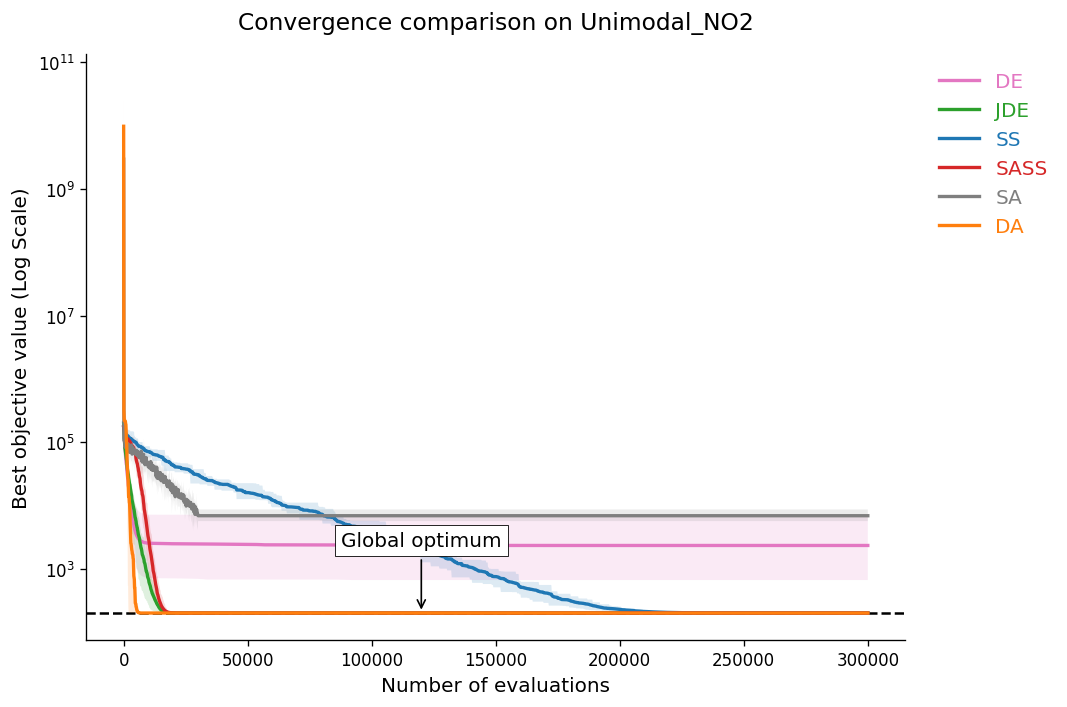

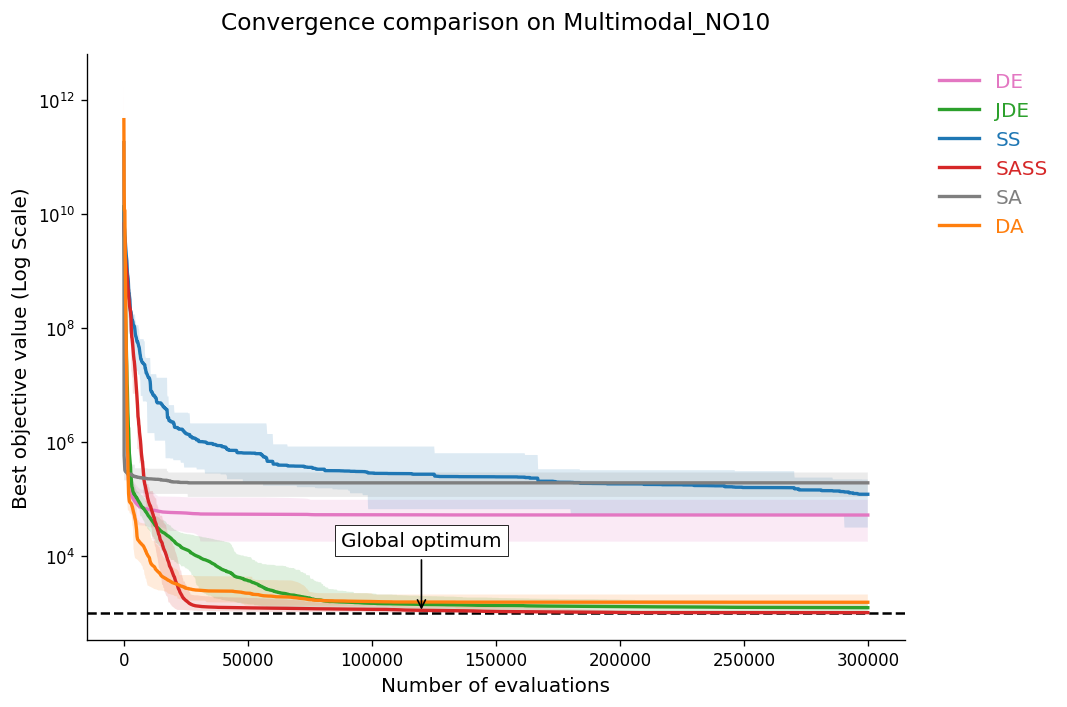

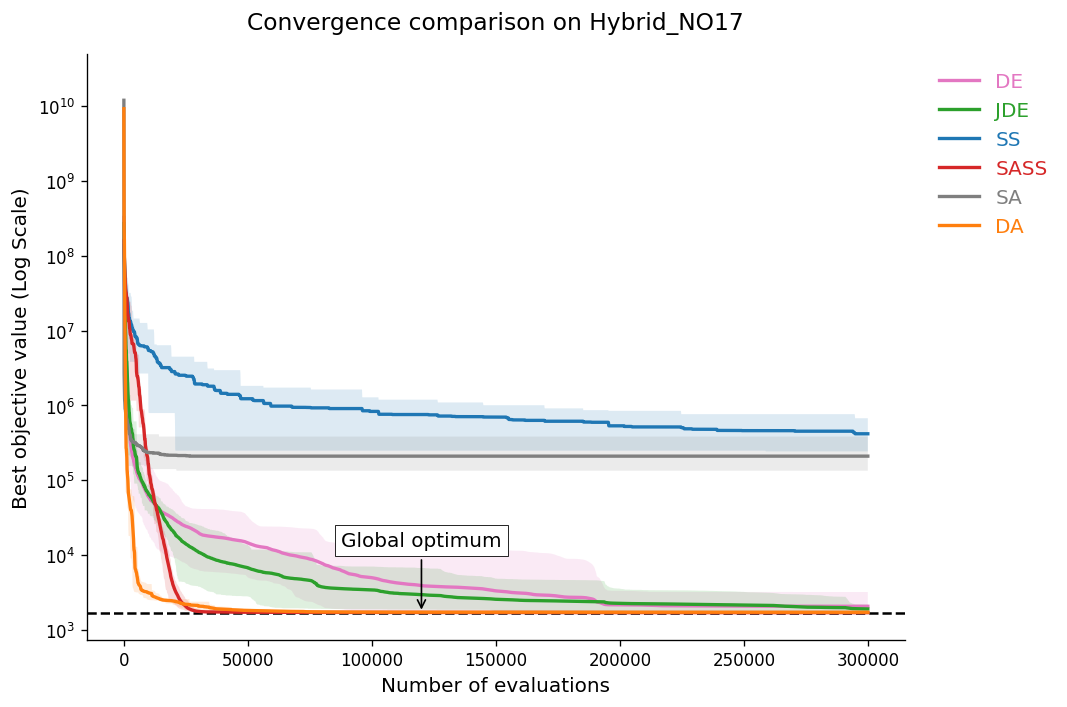

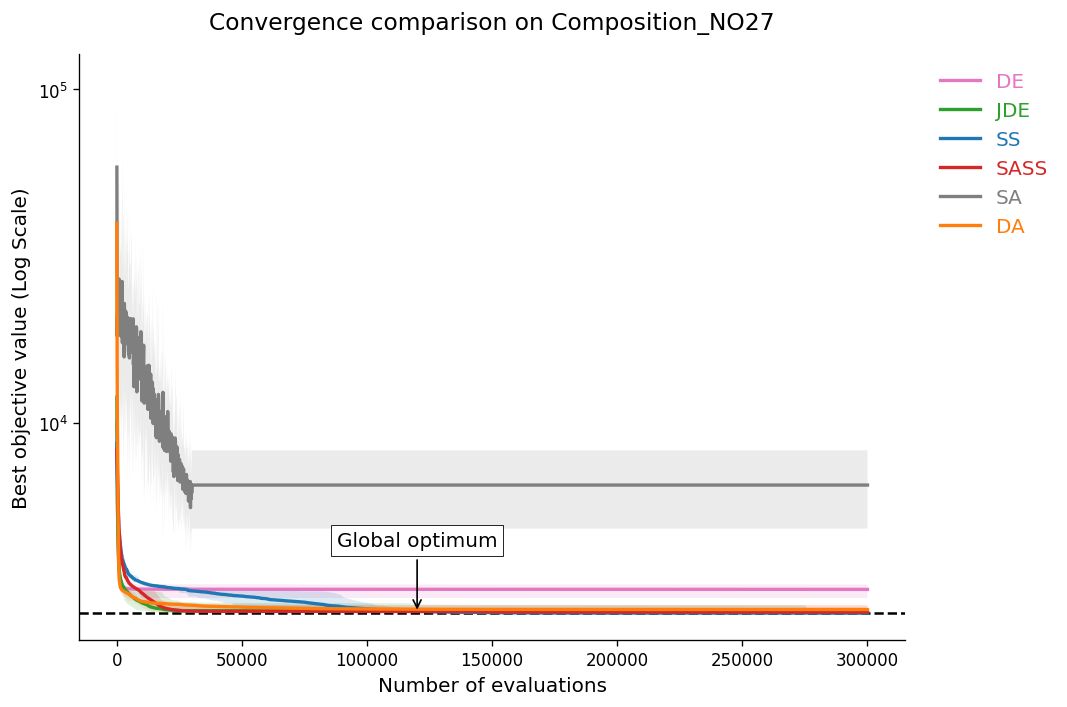

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Stitch your individual algorithm runs into the master dictionary
# Included the new SS_histories
algorithm_histories = {
    "DE": de_histories,
    "JDE": jde_histories,
    "SS": SS_histories,   # <--- ADDED SS
    "SASS": SASS_histories,
    "SA": SA_histories,
    "DA": DA_histories
}

# 2. Your publication-style color palette
# Added a distinct blue for SS to contrast with the red of SASS
colors = {
    "DE": "#e377c2",     # Pink
    "JDE": "#2ca02c",    # Green
    "SS": "#1f77b4",     # Blue <--- ADDED SS
    "SASS": "#d62728",   # Red
    "SA": "#7f7f7f",     # Gray
    "DA": "#ff7f0e"      # Orange
}

# 3. Generate the plots
for problem_name, func in benchmarks.items():
    plt.figure(figsize=(9, 6), dpi=120)
    plotted = False
    ax = plt.gca()
    
    target_score = func.f_global

    for algo_name, histories in algorithm_histories.items():
        if problem_name not in histories:
            continue

        # histories[problem_name] is now a 2D array of shape (10 runs, 3000 points)
        history_matrix = histories[problem_name]
        
        # Calculate Mean, Min, and Max across the 10 runs (axis=0)
        mean_curve = np.mean(history_matrix, axis=0)
        min_curve = np.min(history_matrix, axis=0)
        max_curve = np.max(history_matrix, axis=0)
        
        # --- CRITICAL X-AXIS FIX ---
        # Map the 3,000 data points back to the actual 300,000 Function Evaluation budget
        x = np.linspace(0, 300000, len(mean_curve)) # <--- UPDATED TO 300k
        
        # Get the assigned color
        color = colors.get(algo_name, '#333333')

        # Plot the SOLID line for the Mean
        ax.plot(x, mean_curve + 1e-12, label=algo_name, color=color, linewidth=2.0)
        
        # Add the SHADED MARGIN for variance
        ax.fill_between(x, min_curve + 1e-12, max_curve + 1e-12, color=color, alpha=0.15, edgecolor='none')
        
        plotted = True

    if not plotted:
        plt.close()
        continue

    # ==========================================
    # VISUALIZING THE OPTIMUM
    # ==========================================
    ax.axhline(y=target_score, color='black', linestyle='--', linewidth=1.5, zorder=0)
    
    max_x = 300000 # <--- UPDATED Arrow placement based on 300k FEs
    ax.annotate(
        'Global optimum',
        xy=(max_x * 0.4, target_score),
        xycoords='data',
        xytext=(0, 40),
        textcoords='offset points',
        ha='center',
        fontsize=12,
        bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=0.5),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='black')
    )

    # ==========================================
    # AXIS FORMATTING
    # ==========================================
    plt.yscale('log')
    plt.minorticks_off()
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(f"Convergence comparison on {problem_name}", fontsize=14, pad=15)
    plt.xlabel("Number of evaluations", fontsize=12)
    plt.ylabel("Best objective value (Log Scale)", fontsize=12)

    # ==========================================
    # CUSTOM LEGEND FORMATTING
    # ==========================================
    leg = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=12)
    
    for line, text in zip(leg.get_lines(), leg.get_texts()):
        text.set_color(line.get_color())

    plt.tight_layout()
    plt.show()

### If run the code, just use the code below to plot.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_error_distribution(algorithm_histories, benchmarks, colors):
    for problem_name, func in benchmarks.items():
        records = []
        target_score = func.f_global

        # 1. Collect Error Gaps
        for algo_name, histories in algorithm_histories.items():
            if problem_name not in histories:
                continue

            # Take the final value of each of the 10 runs
            # history_matrix shape is (10, steps)
            final_values = np.array(histories[problem_name])[:, -1]
           
            # Calculate the Error Gap (Absolute difference from optimum)
            # We add a tiny epsilon so 0.0 can be plotted on a log scale
            error_gaps = np.abs(final_values - target_score) + 1e-15

            for gap in error_gaps:
                records.append({
                    "Algorithm": algo_name,
                    "Error Gap": gap
                })

        df = pd.DataFrame(records)

        # 2. Plotting
        plt.figure(figsize=(10, 6), dpi=120)
        ax = plt.gca()

        # Create the "Raincloud" effect using Seaborn
        # The Violin (The Cloud)
        sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
                       split=True, inner=None, alpha=0.4, linewidth=1.5)

        # The Strip (The Rain - individual runs)
        sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,

                      size=5, jitter=0.15, alpha=0.7, edgecolor='white', linewidth=0.5)

        # 3. Professional Styling
        plt.yscale('log')
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


        # Clean L-shape axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.minorticks_off()
        plt.grid(axis='y', linestyle='--', alpha=0.2)


        plt.title(f"Error Gap Distribution over 10 Runs: {problem_name}", fontsize=14, pad=20)
        plt.xlabel("Algorithm", fontsize=12)
        plt.ylabel("Final Error Gap (Log Scale)", fontsize=12)

        plt.tight_layout()
        plt.show()

# Usage
plot_error_distribution(algorithm_histories, benchmarks, colors)

### This is an alternative plotting code, in the case that results were deleted and only have the training logs. Input the training logs in the below data input code, and run the following plotting code.

In [1]:
# 1. MANUALLY INPUT YOUR FINAL SCORES HERE
# Paste the 10 final objective values for each run from your logs.
manual_final_scores = {
    "Unimodal_NO2": {
        "DE": [664.8665, 1776.0663, 1585.2208, 2219.3195, 1625.9715, 2680.9749, 2244.8827, 1233.4797, 6650.0691, 2683.2664],
        "JDE": [200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0],
        "SS": [200.0001, 200.0009, 200.0002, 200.0005, 200.0001, 200.0006, 200.0004, 200.0004, 200.0004, 200.0001], # Unimodal_NO2 log for SS not provided yet, leaving as 200.0
        "SASS": [200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0, 200.0],
        "SA": [6441.4313, 7158.1047, 7055.3127, 7414.8726, 7591.7676, 6302.2538, 5668.4976, 5865.6261, 8652.9651, 6805.9388],
        "DA": [200.0000, 200.0000, 200.0000, 200.0000, 200.0000, 200.0000, 200.0000, 200.0000, 200.0000, 200.0000]
    },
    "Multimodal_NO10": {
        "DE": [66603.6091, 17910.5867, 28075.6058, 65520.4646, 94812.6584, 27452.3198, 34930.7456, 23561.7710, 97310.8035, 69593.5266],
        "JDE": [1539.9257, 1164.2271, 1028.4394, 1128.3550, 1266.2717, 1025.8889, 1372.6056, 1315.0263, 1431.5535, 1144.6118],
        "SS": [167404.5274, 31673.7547, 220525.4579, 132812.7722, 144858.6050, 65640.5610, 113654.5609, 160546.9181, 131451.5886, 48816.9736],
        "SASS": [1018.0286, 1015.9193, 1043.7847, 1017.9092, 1018.6766, 1008.9546, 1006.9647, 1010.9445, 1014.9244, 1020.8941],
        "SA": [204905.0143, 256937.0448, 181733.1783, 244449.7580, 129036.4020, 143316.6659, 293497.1117, 183792.4015, 185526.4488, 109318.3831],
        "DA": [1508.3802, 1789.8512, 1425.8028, 2115.2109, 1376.0783, 1429.7823, 1564.0855, 1212.9250, 1693.3416, 1350.2157]
    },
    "Hybrid_NO17": {
        "DE": [1759.0825, 1785.7036, 1987.7836, 2747.7952, 2160.2003, 1822.5406, 1773.6815, 1817.2759, 1817.6879, 3245.7584],
        "JDE": [2005.8869, 2209.6226, 1734.7790, 2002.2661, 1827.4980, 1758.2369, 1932.2814, 1833.0950, 2160.0434, 1814.5032],
        "SS": [522180.9531, 639209.0085, 316758.4073, 321122.7436, 393058.0797, 675729.6617, 565585.2732, 243913.8827, 249708.1103, 265297.6723],
        "SASS": [1722.3531, 1722.6086, 1722.3696, 1720.1278, 1720.2999, 1721.4500, 1722.4224, 1723.3320, 1722.9393, 1722.2509],
        "SA": [225596.3171, 134876.8402, 361843.3813, 189036.9418, 141624.6337, 171686.4469, 384614.1663, 171602.0579, 172428.7974, 154874.9162],
        "DA": [1742.2477, 1737.6901, 1737.3150, 1745.4946, 1759.8634, 1751.3833, 1731.0637, 1742.2177, 1745.2714, 1737.3768]
    },
    "Composition_NO27": {
        "DE": [3235.8315, 3156.8927, 2995.0664, 3181.2371, 3206.4530, 3167.1034, 3287.7588, 3147.2248, 3168.8828, 3241.1919],
        "JDE": [2717.3245, 2724.7026, 2700.0000, 2700.0000, 2700.0000, 2713.3622, 2700.0000, 2715.6645, 2701.3357, 2700.0000],
        "SS": [2700.0002, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0002, 2700.0002],
        "SASS": [2851.6923, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2700.0000, 2717.7358, 2700.0000],
        "SA": [8294.3535, 4835.1178, 6141.7579, 5921.0376, 7404.0942, 7328.3524, 6270.5020, 5886.7578, 6456.7258, 6745.2568],
        "DA": [2757.4699, 2757.0401, 2760.2636, 2781.5618, 2724.6387, 2764.4475, 2818.6171, 2759.2701, 2782.8044, 2755.3356]
    }
}

# 2. Define the theoretical optimums
target_scores = {
    "Unimodal_NO2": 200.0,
    "Multimodal_NO10": 1000.0,
    "Hybrid_NO17": 1700.0,
    "Composition_NO27": 2700.0
}

# 3. Your publication-style color palette
colors = {
    "DE": "#e377c2",
    "JDE": "#2ca02c",
    "SS": "#1f77b4",
    "SASS": "#d62728",
    "SA": "#7f7f7f",
    "DA": "#ff7f0e"
}

print("✅ Data successfully loaded into memory! Ready to plot.")

✅ Data successfully loaded into memory! Ready to plot.


C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,


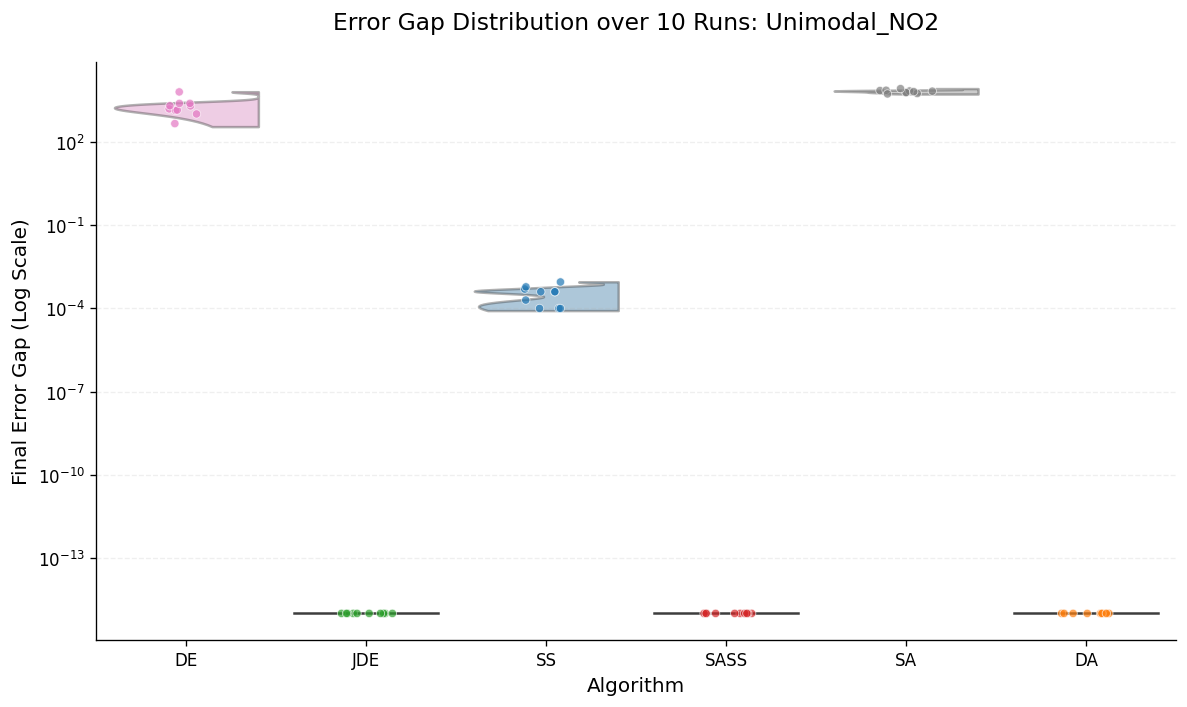

C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,


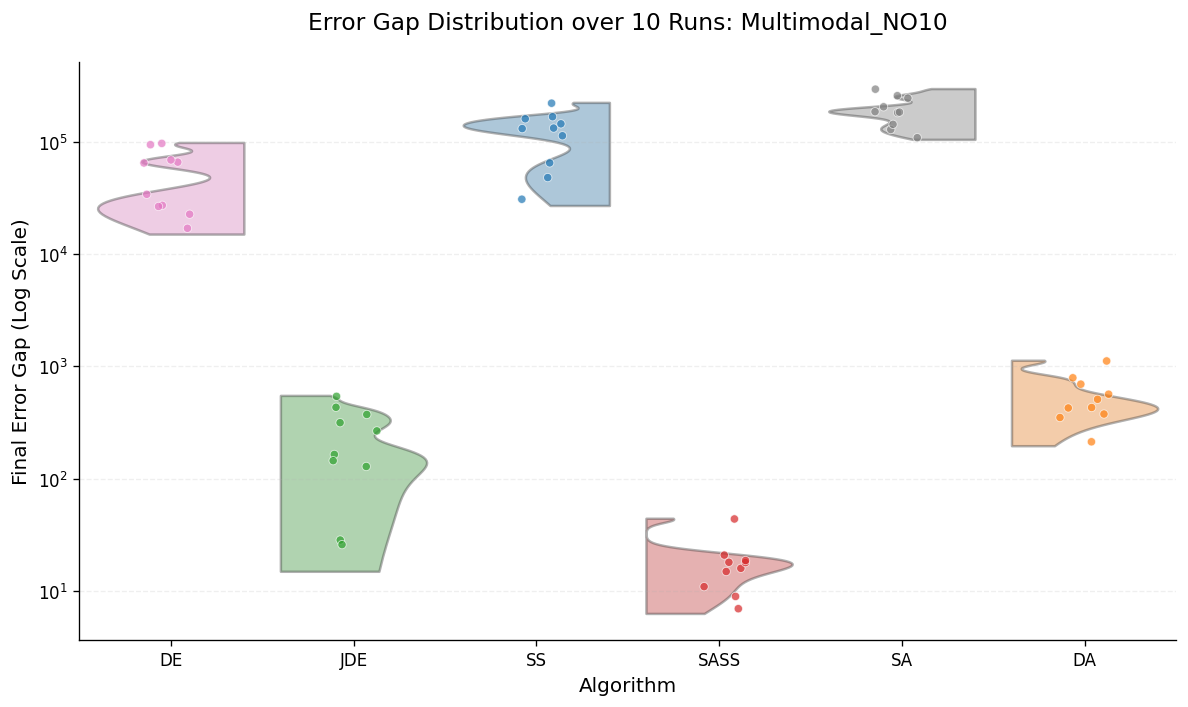

C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,


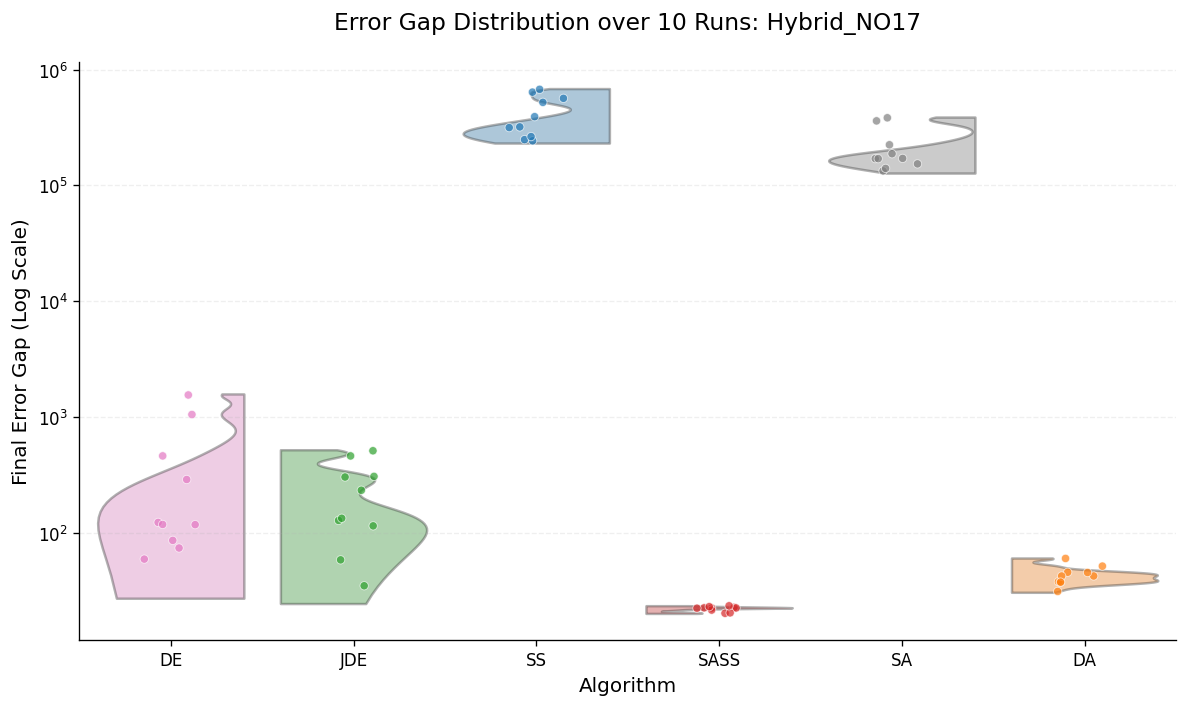

C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
C:\Users\17555\AppData\Local\Temp\ipykernel_35868\2750079070.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,


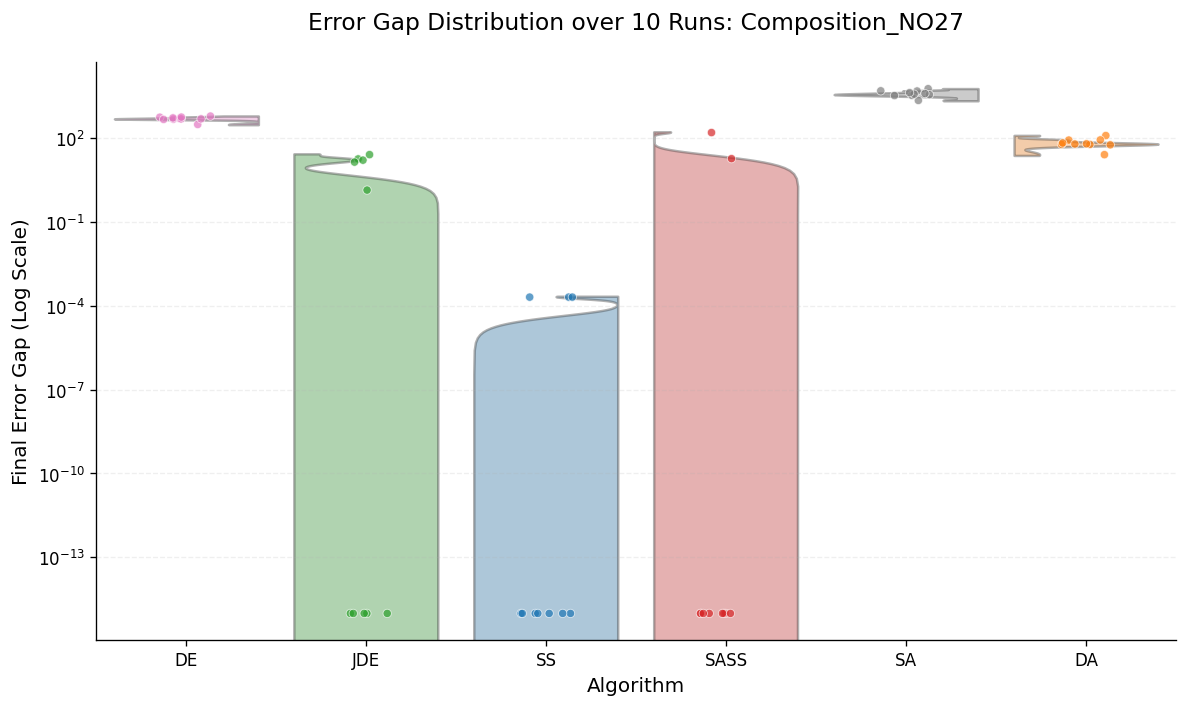

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_manual_error_distribution(manual_scores, targets, colors):
    for problem_name, algo_data in manual_scores.items():
        records = []
        
        # Ensure the problem exists in our target scores dictionary
        if problem_name not in targets:
            print(f"Skipping {problem_name}: No target score defined.")
            continue
            
        target_score = targets[problem_name]
        
        # 1. Collect Error Gaps directly from your manual lists
        for algo_name, final_values in algo_data.items():
            # Convert your list of 10 numbers directly into a NumPy array
            final_values_array = np.array(final_values)
            
            # Calculate the Error Gap (Absolute difference from optimum)
            # Add a tiny epsilon so 0.0 can be plotted on a log scale
            error_gaps = np.abs(final_values_array - target_score) + 1e-15
            
            for gap in error_gaps:
                records.append({
                    "Algorithm": algo_name,
                    "Error Gap": gap
                })
        
        df = pd.DataFrame(records)
        
        # 2. Plotting
        plt.figure(figsize=(10, 6), dpi=120)
        ax = plt.gca()

        # Create the "Raincloud" effect using Seaborn
        # CRITICAL FIX: Added 'cut=0' here to prevent the fake downward tail artifact
        sns.violinplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
                       split=True, inner=None, alpha=0.4, linewidth=1.5, cut=0.2, bw_adjust=0.5)
        
        # The Strip (The Rain - individual runs)
        sns.stripplot(data=df, x="Algorithm", y="Error Gap", palette=colors,
                      size=5, jitter=0.15, alpha=0.7, edgecolor='white', linewidth=0.5)

        # 3. Professional Styling
        plt.yscale('log')
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
        
        # Clean L-shape axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.minorticks_off()
        plt.grid(axis='y', linestyle='--', alpha=0.2)

        plt.title(f"Error Gap Distribution over 10 Runs: {problem_name}", fontsize=14, pad=20)
        plt.xlabel("Algorithm", fontsize=12)
        plt.ylabel("Final Error Gap (Log Scale)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

# Usage (assuming manual_final_scores, target_scores, and colors are defined in your cell above)
plot_manual_error_distribution(manual_final_scores, target_scores, colors)